# Criterios de la Primera y Segunda Derivada para Optimización

Este cuaderno desarrolla y aplica los criterios de la primera y segunda derivada para clasificar puntos críticos de una función y determinar si corresponden a máximos relativos, mínimos relativos o ninguno de los dos.

## Criterio de la Primera Derivada

Sea c un punto crítico de una función f que es continua en un intervalo abierto I que contiene a c. Si f es derivable en el intervalo, excepto posiblemente en c, entonces f(c) puede clasificarse como sigue:

1. **Si f’(x) cambia de positiva a negativa en c**, entonces f tiene un **máximo relativo** en (c, f(c)).

2. **Si f’(x) cambia de negativa a positiva en c**, entonces f tiene un **mínimo relativo** en (c, f(c)).

3. **Si f’(x) es positiva en ambos lados de c o negativa en ambos lados de c**, entonces f(c) **no es ni un mínimo ni un máximo relativo**.

## Criterio de la Segunda Derivada

Método que usa la segunda derivada para efectuar una prueba correspondiente a los máximos y mínimos relativos de una función.

Sea f una función derivable dos veces en un entorno abierto que contiene a x tal que f’(x) = 0 (por lo que x es, consecuentemente, punto crítico de f(x)), entonces con la segunda derivada:

1. **Si f’’(x) < 0**, entonces f tiene **máximo relativo** en (x, f(x)).

2. **Si f’’(x) > 0**, entonces f tiene **mínimo relativo** en (x, f(x)).

3. **Si f’’(x) = 0**, entonces **el criterio no decide**.

In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sympy import symbols, diff, solve

In [3]:
# Definir la variable y la función
x = symbols('x')

# Función de ejemplo: f(x) = x^3 - 6x^2 + 9x + 1
f_x = x**3 - x**2 - 10
f_prime_x = diff(f_x, x)
f_double_prime_x = diff(f_x, x, 2)

print("Función: f(x) =", f_x)
print("Primera derivada: f’(x) =", f_prime_x)
print("Segunda derivada: f’’(x) =", f_double_prime_x)

Función: f(x) = x**3 - x**2 - 10
Primera derivada: f’(x) = 3*x**2 - 2*x
Segunda derivada: f’’(x) = 2*(3*x - 1)


In [4]:
# Encontrar puntos críticos resolviendo f’(x) = 0
critical_points = solve(f_prime_x, x)
print(f"Puntos críticos (donde f’(x) = 0): {critical_points}")
print()

# Analizar sobre la primera derivada
print("="*70)
print("ANÁLISIS CON LA PRIMERA DERIVADA")
print("="*70)
print()

for cp in critical_points:
    cp_val = float(cp)
    
    # Evaluar la derivada a la izquierda y a la derecha del punto crítico
    h = 0.01
    f_prime_left = float(f_prime_x.subs(x, cp_val - h))
    f_prime_right = float(f_prime_x.subs(x, cp_val + h))
    
    print(f"Punto crítico: x = {cp_val:.4f}")
    print(f"  f’(x - h) = {f_prime_left:.6f}  (signo: {'positivo' if f_prime_left > 0 else 'negativo'})")
    print(f"  f’(x + h) = {f_prime_right:.6f}  (signo: {'positivo' if f_prime_right > 0 else 'negativo'})")
    
    # Clasificar según el cambio de signo
    if f_prime_left > 0 and f_prime_right < 0:
        clasificacion = "MÁXIMO RELATIVO (f’ cambia de + a -)"
    elif f_prime_left < 0 and f_prime_right > 0:
        clasificacion = "MÍNIMO RELATIVO (f’ cambia de - a +)"
    else:
        clasificacion = "NO ES MÁXIMO NI MÍNIMO (no hay cambio de signo)"
    
    print(f"  Clasificación: {clasificacion}")
    print()

Puntos críticos (donde f’(x) = 0): [0, 2/3]

ANÁLISIS CON LA PRIMERA DERIVADA

Punto crítico: x = 0.0000
  f’(x - h) = 0.020300  (signo: positivo)
  f’(x + h) = -0.019700  (signo: negativo)
  Clasificación: MÁXIMO RELATIVO (f’ cambia de + a -)

Punto crítico: x = 0.6667
  f’(x - h) = -0.019700  (signo: negativo)
  f’(x + h) = 0.020300  (signo: positivo)
  Clasificación: MÍNIMO RELATIVO (f’ cambia de - a +)



In [5]:
# Analizar sobre la segunda derivada
print("="*70)
print("ANÁLISIS CON LA SEGUNDA DERIVADA")
print("="*70)
print()

results = []
for cp in critical_points:
    cp_val = float(cp)
    f_val = float(f_x.subs(x, cp_val))
    f_double_prime_val = float(f_double_prime_x.subs(x, cp_val))
    
    print(f"Punto crítico: x = {cp_val:.4f}")
    print(f"  f(x) = {f_val:.6f}")
    print(f"  f’’(x) = {f_double_prime_val:.6f}")
    
    # Clasificar según el signo de la segunda derivada
    if f_double_prime_val < 0:
        clasificacion = "MÁXIMO RELATIVO (f’’ < 0)"
    elif f_double_prime_val > 0:
        clasificacion = "MÍNIMO RELATIVO (f’’ > 0)"
    else:
        clasificacion = "CRITERIO NO DECIDE (f’’ = 0)"
    
    print(f"  Clasificación: {clasificacion}")
    print()
    
    results.append({
        'x': cp_val,
        'f(x)': f_val,
        "f’’(x)": f_double_prime_val,
        'Tipo': clasificacion.split('(')[0].strip()
    })

print("\nTabla Resumen:")
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

ANÁLISIS CON LA SEGUNDA DERIVADA

Punto crítico: x = 0.0000
  f(x) = -10.000000
  f’’(x) = -2.000000
  Clasificación: MÁXIMO RELATIVO (f’’ < 0)

Punto crítico: x = 0.6667
  f(x) = -10.148148
  f’’(x) = 2.000000
  Clasificación: MÍNIMO RELATIVO (f’’ > 0)


Tabla Resumen:
       x       f(x)  f’’(x)            Tipo
0.000000 -10.000000    -2.0 MÁXIMO RELATIVO
0.666667 -10.148148     2.0 MÍNIMO RELATIVO


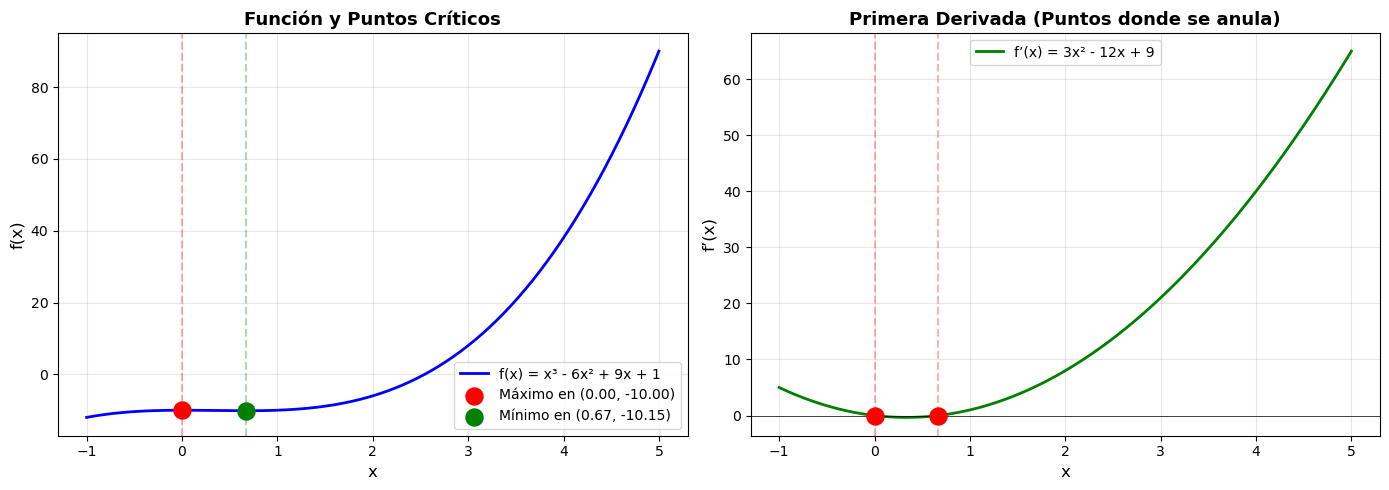

In [6]:
# Visualización de la función y sus puntos críticos
f_lambda = sp.lambdify(x, f_x, 'numpy')
f_prime_lambda = sp.lambdify(x, f_prime_x, 'numpy')

x_vals = np.linspace(-1, 5, 400)
y_vals = f_lambda(x_vals)
y_prime_vals = f_prime_lambda(x_vals)

# Gráfica 1: Función y puntos críticos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Función
ax1.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = x³ - 6x² + 9x + 1')

for cp in critical_points:
    cp_val = float(cp)
    f_val = float(f_x.subs(x, cp_val))
    f_double_prime_val = float(f_double_prime_x.subs(x, cp_val))
    
    # Determinar color según tipo de punto crítico
    if f_double_prime_val < 0:
        color = 'red'
        label_text = f'Máximo en ({cp_val:.2f}, {f_val:.2f})'
    elif f_double_prime_val > 0:
        color = 'green'
        label_text = f'Mínimo en ({cp_val:.2f}, {f_val:.2f})'
    else:
        color = 'orange'
        label_text = f'Indefinido en ({cp_val:.2f}, {f_val:.2f})'
    
    ax1.scatter(cp_val, f_val, color=color, s=150, marker='o', zorder=5, label=label_text)
    ax1.axvline(x=cp_val, color=color, linestyle='--', alpha=0.3)

ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.set_title('Función y Puntos Críticos', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Primera derivada
ax2.plot(x_vals, y_prime_vals, 'g-', linewidth=2, label="f’(x) = 3x² - 12x + 9")
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

for cp in critical_points:
    cp_val = float(cp)
    ax2.scatter(cp_val, 0, color='red', s=150, marker='o', zorder=5)
    ax2.axvline(x=cp_val, color='red', linestyle='--', alpha=0.3)

ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel("f’(x)", fontsize=12)
ax2.set_title('Primera Derivada (Puntos donde se anula)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Tabla de iteraciones con formato estandar y legible
columnas = [
    'Iteración', 'x_k', 'y_k', 'f(x_k, y_k)',
    'df_dx', 'df_dy', 'h_opt', 'Error_paso', 'Norma_gradiente'
]

filas = []

if 'historial' in globals() and historial:
    n_cols = len(historial[0])
    if n_cols == 9:
        for it, xk, yk, fk, dfx, dfy, h_opt, err, ngrad in historial:
            filas.append([it, xk, yk, fk, dfx, dfy, h_opt, err, ngrad])
    elif n_cols == 4:
        for it, xk, gk, err in historial:
            filas.append([it, xk, np.nan, gk, np.nan, np.nan, np.nan, err, np.nan])
    elif n_cols == 2:
        for it, err in historial:
            filas.append([it, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, err, np.nan])

elif 'historial_raiz' in globals() and historial_raiz:
    for it, xk, gk, err in historial_raiz:
        filas.append([it, xk, np.nan, gk, np.nan, np.nan, np.nan, err, np.nan])

elif 'historial_error_min' in globals() and historial_error_min:
    for it, err in historial_error_min:
        filas.append([it, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, err, np.nan])

elif 'historial_error' in globals() and historial_error:
    for it, err in historial_error:
        filas.append([it, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, err, np.nan])

tabla = pd.DataFrame(filas, columns=columnas)

if tabla.empty:
    print('No se encontraron datos de historial para construir la tabla.')
else:
    tabla_fmt = tabla.copy()
    formato = {
        'x_k': '{:.6f}',
        'y_k': '{:.6f}',
        'f(x_k, y_k)': '{:.6f}',
        'df_dx': '{:.6f}',
        'df_dy': '{:.6f}',
        'h_opt': '{:.6f}',
        'Error_paso': '{:.3e}',
        'Norma_gradiente': '{:.3e}'
    }

    for col, fmt in formato.items():
        tabla_fmt[col] = tabla_fmt[col].map(lambda v: '' if pd.isna(v) else fmt.format(v))

    print('Tabla de iteraciones (valores y error):')
    print(tabla_fmt.to_string(index=False))